In [69]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

from assignement2_utils import train_model_test_accuracy, plot_hyperparameter_sweep

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


 # Práctica de aprendizaje automático (parte 2)

Entrega este cuaderno habiendo **ejecutado todas las celdas**. Incluye en la entrega **todos los ficheros necesarios para su ejecución**.

Asegúrate de que la presentación está bien estructurada: Se valorará la **claridad, concisión, y completitud** del informe.

Se trata de una práctica abierta: **explora**. 

1. Describe las características de los datos:
    * Tipo de datos (e.g. [https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)))
    * Número de ejemplos de cada una de las clases.
    * Número y tipo (nominales no ordenados, nominales ordenados, numéricos) de atributos.

Esta información se debería utilizar en el análisis; por ejemplo, si se selecciona un atributo para la predicción, ¿es clara su relevancia por el tipo de información que proporciona de acuerdo con nuestro conocimiento experto sobre el área?
    
2. Detalla la metodología utilizada:
    * Partitición de los datos: tamaño de los conjuntos de entrenamiento y test, uso de estratificación en el muestreo.
    * Preprocesamiento: condificación de los atributos, construcción y selección de características, normalización, etc. (¡solo se debe utilizar la información del consjunto de entrenamiento!)
    * Determinación de los hiperparámetros; por ejemplo, mediante búsqueda en rejilla y validación cruzada.
    * Estimación del error de generalización y su incertidumbre.
2. Resume los resultados en gráficas y tablas.
3. Elabora esta información e ilustra tus observaciones con los resultados obtenidos.
4. Proprociona una recomendación final:
    * Tipo de clasificador.
    * Configuración del clasificador (arquitectura, hiperparámetros, etc.) y método de entrenamiento (función de coste, método de optimización, uso de técnicas de regularización,...)
    * para el predictor final, proporciona los errores de entrenamiento, validación cruzada y test.
5. Resume las conclusiones del análisis.

## 2. Construcción de un clasificador en una base de datos real

In [2]:
df = pd.read_csv('./data/german_credit_data.csv', sep=';')
# Source: https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)
# This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix

print(df.shape)
df.head(5)

(1000, 21)


,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [3]:
class_label = 'default'
feature_names = list(df.columns)
feature_names.remove(class_label)
print(feature_names)
X = df[feature_names].values
y = df[class_label].values

['account_check_status ', 'duration_in_month ', 'credit_history ', 'purpose ', 'credit_amount ', 'savings ', 'present_emp_since ', 'installment_as_income_perc ', 'personal_status_sex ', 'other_debtors ', 'present_res_since ', 'property ', 'age ', 'other_installment_plans ', 'housing ', 'credits_this_bank ', 'job ', 'people_under_maintenance ', 'telephone ', 'foreign_worker']


**Estadísticos básicos de cada atributo:**

In [4]:
df.describe()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.300000,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,0.458487,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,0.000000,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,0.000000,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,0.000000,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,1.000000,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,1.000000,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


**Datos codificados de forma numérica**

In [5]:
df = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')
class_label = 'Class'
feature_names = list(df.columns)
feature_names.remove(class_label)
print(feature_names)
X = df[feature_names].values
y = df[class_label].values

['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']


**Histogramas suavizados de cada atributo en cada clase. El color indica la clase ("default"/"no default"):**

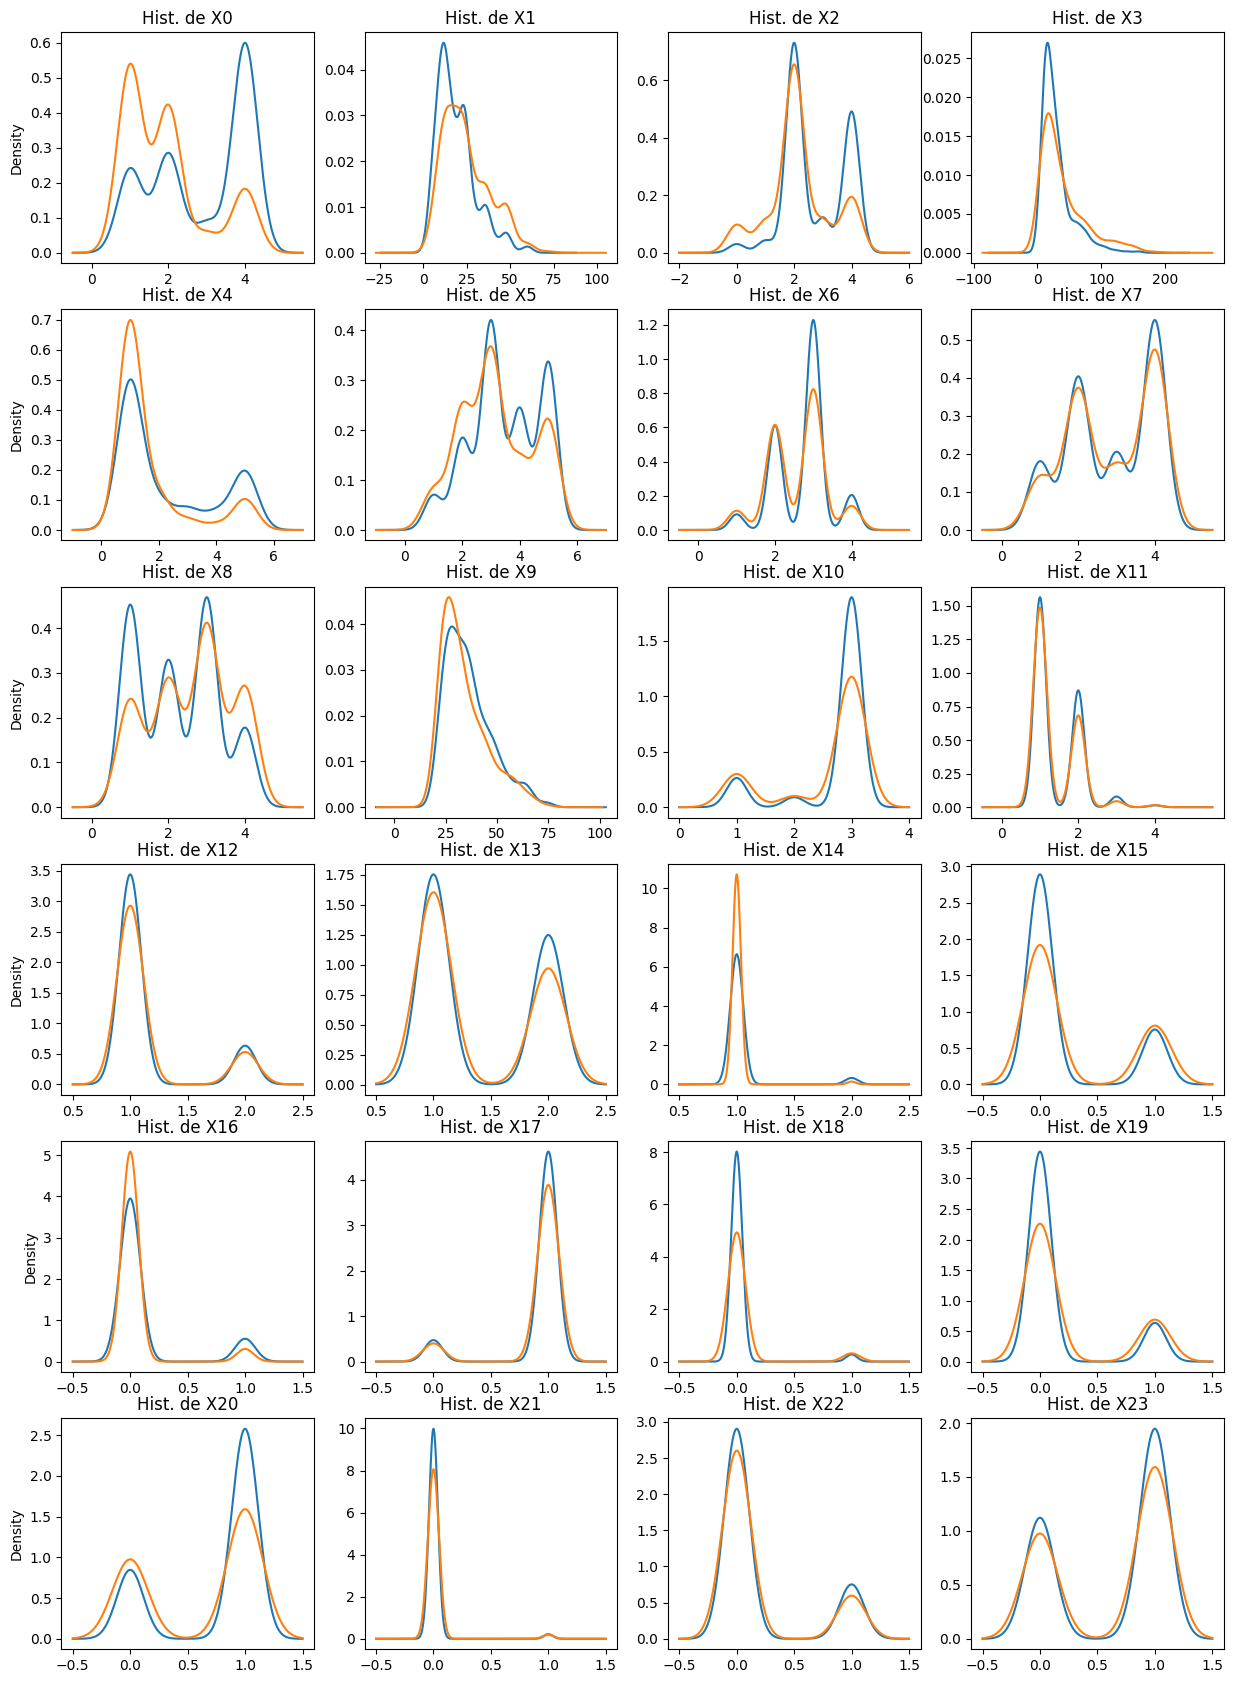

In [6]:
plt.figure(figsize=(15, 21))
n_cols_plot = 4
n_rows_plot = int(len(feature_names) / n_cols_plot)
for i,n in enumerate(feature_names):
    plt.subplot(n_rows_plot, n_cols_plot, i+1)
    aux = 'Density' if i%n_cols_plot == 0 else ''
    df.groupby('Class')[n].plot(kind='kde', title='Hist. de '+n)
    plt.ylabel(aux)

## Entrenamiento de un modelo y evaluación de su calidad usando 5-fold cross validation

La siguiente celda entrena un modelo y lo evalúa en varias particiones training-test diferentes de los datos. El resultado es un score medio junto a su desviación estándar. El tipo de modelo (Naïve Bayes / árbol de decisión / knn/ regresión logística / red neuronal) y parámetros empleados deberán ser seleccionados para que dicho resultado sea el mejor posible.

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
# otros clasificadores

clf = KNeighborsClassifier(n_neighbors=1) # DecisionTreeClassifier(max_depth=3)
scores = cross_val_score(clf, X, y, cv=10) # 10-fold cross-validation
print('Precisión en cada una de las particiones: ', scores)
print('Estimación de la precisión por validación cruzada: {:.2f} +/- {:.2f}'.format(scores.mean(), scores.std()))

Precisión en cada una de las particiones:  [0.65 0.62 0.72 0.66 0.63 0.71 0.59 0.7  0.62 0.66]
Estimación de la precisión por validación cruzada: 0.66 +/- 0.04


## Responde aquí a las siguientes preguntas:

* Haz una gráfica que muestre la dependencia de la precisión de un clasificador de vecinos próximos con el número de vecinos. Si es más conveniente, utiliza gráficas en escala logarítmica para alguno de los ejes (`semilogx`, `semilogy`, `loglog`).
* Utilizando los conceptos de sub- y sobreajuste:
    * Comenta los resultados cuando el número de vecinos es pequeño.
    * Comenta los resultados cuando el número de vecinos es grande.
    * Explica el significado del valor de la precisión cuando el número de vecinos toma el valor mayor posible.
* ¿Cuál es la mejor precisión que se alcanza con k-nn y para qué k (valor de `n_neighbours`)?
* ¿Cuál es la mejor precisión que se alcanza con un árbol de decisión y con qué profundidad máxima (valor de `max_depth`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con la profundidad máxima del árbol. Comenta los resultados.
* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con una sola capa oculta y con qué configuración (valor de `hidden_layer_sizes`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de nodos en la capa oculta. Comenta los resultados.
* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con varias capas ocultas y con qué configuración? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de capas ocultas, suponiendo constante el número de nodos en cada capa oculta. Comenta los resultados.
* Resume los resultados y conclusiones del estudio realizado.

**Además de gráficas, puede ser conveniente presentar los resultados en forma de tablas.**


## Procesamiento

En ocasiones, en lugar de utilizar modelos más complejos, es más útil invertir más tiempo en el procesamiento de los datos para conseguir mejores resultados.

En este apartado vas a investigar mecanismos para preparar los datos y obtener (en principio) mejores resultados: construcción y selección de atributos, preprocesamiento (detección de outliers, missing values, centrado y escalado).

Razona por qué decides probar o ignorar alguno de estos métodos, y cómo cambian los resultados al aplicarlos (puedes crear tantas celdas como consideres oportunas).
Usa tablas, gráficas y código, según sea necesario, para ilustrar tus observaciones.

In [8]:
# incluye aquí código

## ¿Cómo se determina el valor de los hiperparámetros?

Para determinar el valor de los hiperparámetros de un modelo realizaremos una búsqueda en una rejilla. De entre los valores considerados seleccionaremos los que maximicen la estimación por validación cruzada (K = 10) de la tasa de acierto.

Adapta el código que encontrarás en 
[https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html#sphx-glr-auto-examples-model-selection-plot-grid-search-digits-py](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html#sphx-glr-auto-examples-model-selection-plot-grid-search-digits-py)
a este problema. 

En los tutoriales
[https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html](
    https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
[https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
hay información sobre cada uno de los hiper-parámetros. 
Puedes elegir el conjunto de hiperparametros en el que se realiza la optimización. 
Antes de elegir la rejilla de hiperparámetros, asegúrate de que entiendes su para asegurarte que tiene sentido la búsqueda.

In [9]:
# incluye aquí código

## ¿Cómo se estima el error de generalización?

Estimaremos el error de generalización de cada clasificador usando *Nested Cross Validation*. 


Adapta el código que encontrarás en https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html para resolver este problema con una red neuronal. 


In [10]:
# incluye aquí código

## ¿Cuál es el mejor clasificador?

* De acuerdo con los resultados de los anteriores apartados, indica cuál es el mejor clasificador encontrado.
* ¿Cuáles son los valores de los hiperparámetros utilizados para configurar y entrenar tal  clasificador?
* ¿cuáles son los valores de los parámetros del clasificador entrenado?
* Proporciona una estimación del error de generalización por validación cruzada, así como de la incertidumbre de dicha estimación.


## Conclusiones.
Resume los resultados y conclusiones del estudio que has realizado.


---

## Soluciones de la tarea

1. Análisis de los datos usados

Se trata de un conjunto de datos tabular de clasificación supervisada (con etiquetas) para riesgo de crédito: cada fila representa un solicitante (o una operación de crédito) descrito por variables socioeconómicas y del préstamo, y la tarea consiste en predecir la etiqueta `default`, codificada como 0 o 1. En el fichero proporcionado hay 1000 observaciones en total, con 700 ejemplos en la clase `default = 0` y 300 ejemplos en la clase `default = 1`, por lo que el conjunto está moderadamente desbalanceado.

En cuanto a los atributos, el dataset contiene 20 variables explicativas (no se incluye la etiqueta). Estas variables combinan información numérica y categórica. En particular, hay 7 atributos numéricos (por ejemplo, `duration_in_month`, `credit_amount`, `age`, etc.), 3 atributos nominales ordenados (categóricos con un orden natural en sus niveles, como `account_check_status`, `savings` y `present_emp_since`) y 10 atributos nominales no ordenados (categóricos sin orden inherente, como `purpose`, `housing`, `job`, `telephone`, `foreign_worker`, entre otros). Esta mezcla de tipos hace necesario tratar de forma distinta las variables categóricas.

Por la razón anterior, usaremos en los ejercicios la versión numérica del dataset inicial: `german_credit_data_numeric`. En este archivo, algunas de las variables categóricas han sido previamente transformadas a formato numérico mediante técnicas de codificación ( binarización, one-hot encoding). Como consecuencia, una misma característica categórica original puede dar lugar a varias columnas numéricas, lo que explica que el número total de atributos aumente respecto al dataset original. Este preprocesado no introduce nueva información, sino que adapta la representación de los datos para que pueda ser utilizada directamente por modelos de aprendizaje automático que requieren entradas numéricas.

> #### Objetivo del aprendizaje en la tarea
Es importante motivar el objetivo de la tarea previo a empezar a resolver las cuestiones planteadas. El objetivo de esta tarea de aprendizaje supervisado es construir modelos capaces de predecir si un solicitante de crédito incurrirá en impago (*default*) o no, a partir de la información contenida en los atributos del dataset. Estas variables recogen características socioeconómicas del solicitante y detalles del propio préstamo, y constituyen la base para inferir el **riesgo de crédito** asociado a cada operación. El problema se formula como una tarea de clasificación binaria, en la que el modelo debe aprender patrones en los datos históricos que permitan discriminar entre solicitantes con mayor y menor probabilidad de incumplimiento, evaluando posteriormente su capacidad de generalización sobre datos no vistos.


Dado que el objetivo es evaluar la **capacidad de generalización** de cada clasificador frente a datos no vistos, se evita basar el análisis en el comportamiento sobre el conjunto de entrenamiento, ya que este puede estar distorsionado por efectos de sobreajuste. Por este motivo, las conclusiones se apoyan exclusivamente en el error de test, que constituye la métrica relevante para comparar distintas configuraciones de los modelos y seleccionar los valores óptimos de sus hiperparámetros.

#### Parte 1
* Haz una gráfica que muestre la dependencia de la precisión de un clasificador de vecinos próximos con el número de vecinos. Si es más conveniente, utiliza gráficas en escala logarítmica para alguno de los ejes (`semilogx`, `semilogy`, `loglog`).

Antes de empezar a responder las preguntas, es conveniente escalar los datos que vienen en el dataset `german_credit_data_numeric.csv`. Esto es razonable ya que las variables numéricas presentan escalas muy distintas: algunas toman valores grandes (como `credit_amount` o `duration_in_month`), mientras que otras están acotadas a rangos pequeños. Sin escalado, las variables de mayor magnitud dominan el aprendizaje del modelo, independientemente de su relevancia real.

Además, varios de los modelos usados en este ejercicio (como k-NN, regresión logística o redes neuronales) son sensibles a la escala, ya que se basan en distancias o en optimización por gradiente. El escalado permite que todas las características contribuyan de forma comparable, mejora la estabilidad numérica y facilita una convergencia más eficiente del entrenamiento.


In [48]:
# global hyperparameters
seed = 0
test_size = 0.3

In [ ]:
# We re-load the numeric dataset to avoid any interference from previous steps
df = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')

class_label = 'Class' #class -> equivalent to default in non-numeric dataset
feature_names = list(df.columns)
feature_names.remove(class_label)

X = df[feature_names].values
y = df[class_label].values

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=123, stratify=y
)

n_samples_train = X_train.shape[0]
n_samples_test = X_test.shape[0]
n_features = X_train.shape[1]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [45]:
print(n_samples_train, n_samples_test, n_features)

700 300 24


En la anterior celda realizamos el preprocesado básico necesario antes de entrenar los modelos de aprendizaje automático. En primer lugar, se separan las variables explicativas (`X`) de la etiqueta (`y`), donde `Class` representa la variable objetivo que indica la clase asociada a cada solicitante de crédito. A continuación, el conjunto de datos se divide en subconjuntos de entrenamiento y test, **utilizando una partición del 70%–30%** y estratificación respecto a la etiqueta para preservar la proporción original de clases en ambos conjuntos. Posteriormente, se aplica un escalado estándar a las variables de entrada mediante `StandardScaler`. Este procedimiento centra cada característica restándole su media y la normaliza dividiéndola por su desviación típica. El escalador se ajusta exclusivamente con los datos de entrenamiento, de modo que los parámetros del escalado (medias y desviaciones) se calculan sin utilizar información del conjunto de test. Finalmente, estos mismos parámetros se emplean para transformar el conjunto de test, garantizando una evaluación correcta del rendimiento de los modelos.

Seguidamente se evalúa el rendimiento de un clasificador *k*-NN para distintos valores del número de vecinos. Se define un rango de valores de k que va desde 1 hasta el número total de muestras de entrenamiento y, para cada uno de ellos, se entrena el modelo correspondiente y se calcula su precisión sobre el conjunto de test. Como resultado, se obtiene la evolución de la *accuracy* en función de k, así como el valor de k que proporciona la mejor precisión y la precisión máxima alcanzada. 

Para el plot elegimos mostrar el eje x (núm. de vecinos próximos) en escala logarítmica para una mayor visibilidad.


In [71]:
k_values = range(1, n_samples_train + 1)

params_kNN, acc_kNN, best_k_kNN, best_acc_kNN = train_model_test_accuracy(
    model_from_param=lambda k: KNeighborsClassifier(n_neighbors=int(k)),
    param_values=k_values,
    X_train=X_train_scaled, y_train=y_train,
    X_test=X_test_scaled, y_test=y_test,
    
)

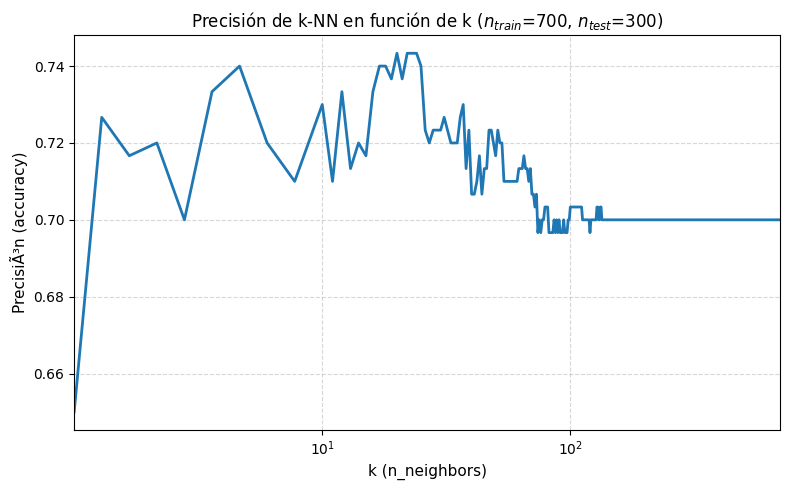

In [72]:
plot_hyperparameter_sweep(
    x_values=params_kNN,
    y_values=acc_kNN,
    x_label="k (n_neighbors)",
    title=rf"Precisión de k-NN en función de k ($n_{{train}}$={n_samples_train}, $n_{{test}}$={n_samples_test})",
    xscale="symlog",
    xlim=(1, n_samples_train),
    symlog_linthresh=10,
)

>Figura 1: Precisión de las predicciones del modelo kNN en el conjunto de test en función del número de vecinos k.

* Utilizando los conceptos de sub- y sobreajuste:
    * Comenta los resultados cuando el número de vecinos es pequeño.
    * Comenta los resultados cuando el número de vecinos es grande.
    * Explica el significado del valor de la precisión cuando el número de vecinos toma el valor mayor posible.

En función de los resultados de la Figura 1:

- **Valores pequeños de k (p. ej., 1–10):** el clasificador presenta sesgo bajo y alta varianza. Las decisiones se toman a partir de muy pocos vecinos, lo que lo hace extremadamente sensible al ruido y a observaciones atípicas. En la gráfica esto se manifiesta como fuertes oscilaciones de la precisión ante pequeños cambios en k, un comportamiento característico de **sobreajuste**.

- **Valores grandes de k (p. ej., k > 50–100):** el modelo promedia la información de muchos vecinos, reduciendo la varianza pero incrementando el sesgo. Como consecuencia, pierde capacidad para capturar estructuras locales relevantes y la precisión disminuye progresivamente hasta estabilizarse. Este régimen corresponde al **subajuste**, donde el modelo es demasiado rígido.

- **Valor máximo de k (k = $n_{{train}}$):** todos los puntos de test consideran como vecinos a todo el conjunto de entrenamiento. En este caso, k-NN se comporta como un clasificador trivial que predice siempre la clase mayoritaria del entrenamiento. Por ello, la precisión converge al porcentaje de la clase dominante en el conjunto de test (en torno a 0.70%), reflejando el desbalance de clases más que la capacidad predictiva del modelo.


* ¿Cuál es la mejor precisión que se alcanza con k-nn y para qué k (valor de `n_neighbours`)?

In [52]:
print(f"Mejor k: {best_k_kNN} con precisión de test: {best_acc_kNN:.2f}")

Mejor k: 20 con precisión de test: 0.74


La mejor precisión alcanzada por el clasificador k-NN en este experimento es **0.74**, y se obtiene para un valor de **k = 20** (es decir, `n_neighbors = 12`). Este resultado sugiere que un tamaño de ''vecindario'' intermedio proporciona un buen equilibrio entre sobreajuste y subajuste, permitiendo capturar patrones locales relevantes sin ser excesivamente sensible al ruido.

* ¿Cuál es la mejor precisión que se alcanza con un árbol de decisión y con qué profundidad máxima (valor de `max_depth`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con la profundidad máxima del árbol. Comenta los resultados.

Exploramos ahora el efecto de la profundidad máxima del árbol de decisión sobre su rendimiento. Primero, definimos un rango de valores posibles para `max_depth`, desde árboles muy poco profundos hasta árboles sin límite de profundidad. A continuación, para cada uno de estos valores se entrena un modelo de árbol de decisión utilizando el conjunto de entrenamiento y se calcula su precisión sobre el conjunto de test mediante la función `train_model_test_accuracy`. Por último, se representa gráficamente la dependencia de la precisión con la profundidad del árbol y se muestra el valor de `max_depth` que alcanza la mejor precisión.

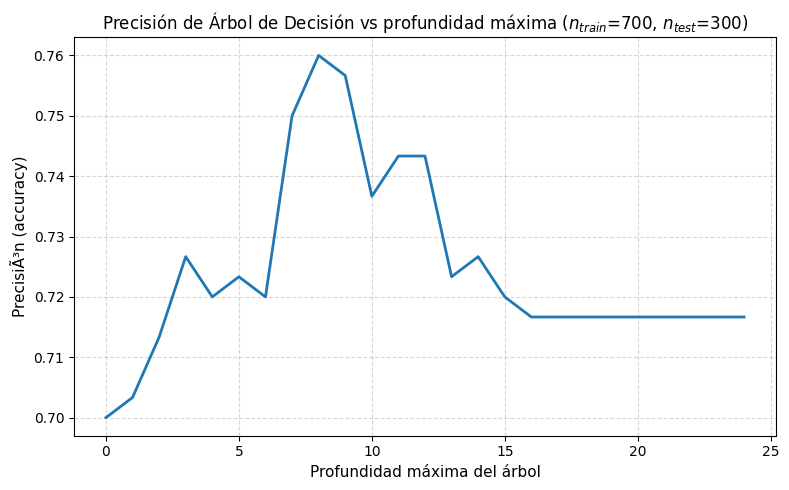

In [ ]:
depth_values = list(range(1, n_features + 1)) + [None]

params_tree, acc_tree, best_depth_tree, best_acc_tree = train_model_test_accuracy(
    model_from_param=lambda d: DecisionTreeClassifier(
        max_depth=d, random_state=0
    ),
    param_values=depth_values,
    X_train=X_train_scaled, y_train=y_train,  
    X_test=X_test_scaled, y_test=y_test,
)

plot_hyperparameter_sweep(
    x_values=range(len(params_tree)),
    y_values=acc_tree,
    x_label="Profundidad máxima del árbol",
    title=rf"Precisión de Árbol de Decisión vs profundidad máxima ($n_{{train}}$={n_samples_train}, $n_{{test}}$={n_samples_test})",
    xscale="linear",
)

>Figura 2: Precisión de las predicciones del árbol de decisión en el conjunto de test en función de la profundidad máxima de este.

In [80]:
print("Mejor precisión (Árbol de decisión):", best_acc_tree, "con max_depth =", best_depth_tree)

Mejor precisión (Árbol de decisión): 0.76 con max_depth = 9


La gráfica evidencia una dependencia clara de la precisión con la profundidad máxima del árbol de decisión. Para valores pequeños de `max_depth`, el árbol es demasiado simple para capturar la estructura de los datos, lo que da lugar a **subajuste**, caracterizado por **alto sesgo y baja varianza** y, en consecuencia, una precisión limitada. A medida que aumenta la profundidad, el modelo gana capacidad expresiva y la precisión mejora, alcanzando su valor máximo de **0.75** para **`max_depth = 9`**, donde se obtiene un equilibrio adecuado entre sesgo y varianza.

A partir de este punto, incrementar la profundidad no solo deja de aportar mejoras, sino que reduce el rendimiento sobre el conjunto de test. Este descenso y posterior estabilización de la precisión es indicativo de **sobreajuste**, asociado a **bajo sesgo y alta varianza**, ya que el árbol comienza a aprender detalles específicos y ruido del conjunto de entrenamiento que no generalizan bien. En este problema, una profundidad intermedia del árbol resulta ser la opción óptima para maximizar la capacidad predictiva manteniendo una buena generalización.

* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con una sola capa oculta y con qué configuración (valor de `hidden_layer_sizes`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de nodos en la capa oculta. Comenta los resultados.

En la siguiente celda se realiza el entrenamiento y test de la red neuronal. En cuanto a los hiperparámetros del optimizador: el parámetro `hidden_layer_sizes` determina el número de nodos en la capa oculta y, por tanto, la capacidad de la red. Se utiliza la función de activación `relu` para introducir no linealidad y facilitar una optimización eficiente. El entrenamiento se realiza con el optimizador `adam`, que adapta automáticamente la tasa de aprendizaje y suele converger de forma estable. El número máximo de iteraciones se limita con `max_iter`, y `early_stopping` detiene el entrenamiento cuando la mejora se estanca, evitando entrenamientos innecesarios. 

In [ ]:
hidden_neurons = list(range(1, 200, 1))  

params_NN, acc_NN, best_h_NN, best_acc_NN = train_model_test_accuracy(
    model_from_param=lambda h: MLPClassifier(
        hidden_layer_sizes=(int(h),),
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=0,
    ),
    param_values=hidden_neurons,
    X_train=X_train_scaled, y_train=y_train,  
    X_test=X_test_scaled, y_test=y_test,
)

c:\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


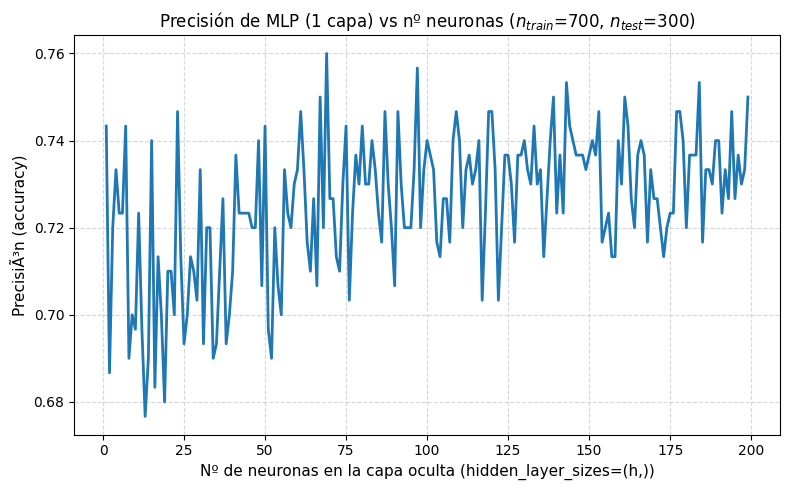

In [117]:
plot_hyperparameter_sweep(
    x_values=params_NN,
    y_values=acc_NN,
    x_label="Nº de neuronas en la capa oculta (hidden_layer_sizes=(h,))",
    title=rf"Precisión de MLP (1 capa) vs nº neuronas ($n_{{train}}$={n_samples_train}, $n_{{test}}$={n_samples_test})",
    xscale="linear",
)

> Figura 3. Precisión de las predicciones de la red neuronal unicapa en el conjunto de test en función del número de neuronas ocultas.

In [118]:
print("Mejor precisión (MLP 1 capa):", best_acc_NN, "con hidden_layer_sizes =", (int(best_h_NN),))

Mejor precisión (MLP 1 capa): 0.76 con hidden_layer_sizes = (69,)


La mejor precisión alcanzada por la red neuronal con una sola capa oculta es **0.76**, y se obtiene con la configuración **`hidden_layer_sizes = (69,)`**, es decir, una única capa oculta con 69 nodos. En la figura se observa que, para un número reducido de nodos, la red presenta un rendimiento inferior debido a su capacidad limitada, lo que se traduce en **subajuste**. Al incrementar el número de nodos, la precisión mejora y pasa a oscilar alrededor de un *plateau* en torno a $0.73$–$0.75$, indicando que a partir de cierto tamaño la red dispone de capacidad suficiente para capturar los patrones relevantes del problema.

Una vez alcanzado este régimen, aumentar el número de nodos no conduce a mejoras sistemáticas ni a un deterioro progresivo del rendimiento en el conjunto de test. Este comportamiento es coherente con la presencia de **regularización** en el entrenamiento, en particular una penalización **L2** sobre los pesos (controlada por el parámetro `alpha`), que limita la complejidad efectiva del modelo incluso cuando crece el número de parámetros. Las pequeñas fluctuaciones observadas en la precisión se explican principalmente por la naturaleza estocástica del proceso de entrenamiento, más que por la aparición de un sobreajuste claro.

* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con varias capas ocultas y con qué configuración? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de capas ocultas, suponiendo constante el número de nodos en cada capa oculta. Comenta los resultados.

In [ ]:
nodes_per_layer = 8
max_layers = 30

arch_values = [
    tuple([nodes_per_layer] * L)
    for L in range(1, max_layers + 1)
]
params_DNN, acc_DNN, best_arch_DNN, best_acc_DNN = train_model_test_accuracy(
    model_from_param=lambda arch: MLPClassifier(
        hidden_layer_sizes=arch,
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=0,
    ),
    param_values=arch_values,
    X_train=X_train_scaled, y_train=y_train,
    X_test=X_test_scaled, y_test=y_test,
)

Mejor precisión (MLP varias capas): 0.7266666666666667 con hidden_layer_sizes = (8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8)


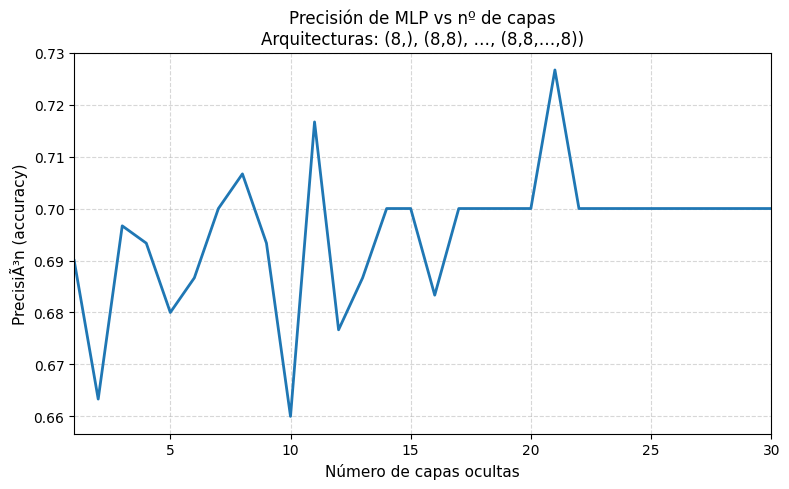

In [ ]:
n_layers = [len(arch) for arch in params_DNN]

plot_hyperparameter_sweep(
    x_values=n_layers,
    y_values=acc_DNN,
    x_label="Número de capas ocultas",
    title=(
        "Precisión de MLP vs nº de capas\n"
        "Arquitecturas: (8,), (8,8), …, (8,8,…,8))"
    ),
    xscale="linear",
    xlim=(1, max_layers),
)

> Figura 4. Precisión de las predicciones de la red neuronal profunda en el conjunto de test en función del número de capas, para un número fijo de neuronas por capa.

La mejor precisión alcanzada por la red neuronal con varias capas ocultas es **0.7267**, y se obtiene para la red con **21 capas ocultas** y **8 neuronas en cada capa**. La gráfica muestra que, para un número reducido de capas, la precisión es relativamente baja y presenta fluctuaciones, lo que indica una capacidad limitada y una optimización inestable. Al aumentar el número de capas, el rendimiento mejora ligeramente y alcanza un máximo para profundidades intermedias-altas.

Sin embargo, a partir de ese punto no se observa una mejora sistemática al seguir incrementando la profundidad, y la precisión tiende a estabilizarse en torno a valores cercanos a 0.70. Este comportamiento sugiere que, manteniendo constante el número de nodos por capa, añadir más capas no aporta un aumento significativo de la capacidad de generalización del modelo en este problema. Las oscilaciones observadas se deben principalmente a la dificultad de optimizar redes más profundas y a la naturaleza estocástica del entrenamiento, más que a un beneficio real de aumentar la profundidad.

* Resume los resultados y conclusiones del estudio realizado.

In [131]:
model_results = [
    {
        "modelo": "k-NN",
        "hiperparametro": "n_neighbors",
        "espacio_busqueda": f"1..{n_samples_train}",
        "n_valores_probados": len(params_kNN),
        "mejor_valor": int(best_k_kNN),
        "mejor_accuracy_test": float(best_acc_kNN)    },
    {
        "modelo": "DecisionTree",
        "hiperparametro": "max_depth",
        "espacio_busqueda": f"1..{n_features} + None",
        "n_valores_probados": len(params_tree),
        "mejor_valor": best_depth_tree,
        "mejor_accuracy_test": float(best_acc_tree)    },
    {
        "modelo": "MLP_1_capa",
        "hiperparametro": "hidden_layer_sizes",
        "espacio_busqueda": f"{min(hidden_neurons)}..{max(hidden_neurons)}",
        "n_valores_probados": len(params_NN),
        "mejor_valor": (int(best_h_NN),),
        "mejor_accuracy_test": float(best_acc_NN)    },
    {
        "modelo": "MLP_profundo",
        "hiperparametro": "hidden_layer_sizes",
        "espacio_busqueda": f"capas=1..{max_layers}, neuronas_por_capa={nodes_per_layer}",
        "n_valores_probados": len(params_DNN),
        "mejor_valor": "10 capas con 8 neuronas cada una",
        "mejor_accuracy_test": float(best_acc_DNN)
    },
]
df_resumen_modelos = pd.DataFrame(model_results)
print(df_resumen_modelos)

         modelo      hiperparametro                  espacio_busqueda  \
0          k-NN         n_neighbors                            1..700   
1  DecisionTree           max_depth                      1..24 + None   
2    MLP_1_capa  hidden_layer_sizes                            1..199   
3  MLP_profundo  hidden_layer_sizes  capas=1..30, neuronas_por_capa=8   

   n_valores_probados                       mejor_valor  mejor_accuracy_test  
0                 700                                20             0.743333  
1                  25                                 9             0.760000  
2                 199                             (69,)             0.760000  
3                  30  10 capas con 8 neuronas cada una             0.726667  


Los resultados de este estudio se pueden resumir en los siguientes párrafos:

En k-NN se observa un patrón sesgo–varianza muy claro: con $k$ pequeño la precisión es inestable (alta varianza y tendencia al sobreajuste), mientras que al aumentar $k\$ mejora hasta un óptimo y luego cae. El mejor resultado se obtiene con **$k=20$** y *accuracy* $\approx 0.743$ Para $k$ grande, el modelo promedia demasiado, entra en **subajuste** y la curva se aplana cerca de **0.70**, reflejando un comportamiento parecido al voto por mayoría.

El árbol de decisión muestra la relación más interpretable entre complejidad y rendimiento: con profundidades bajas hay **subajuste** (alto sesgo), la precisión crece hasta el máximo en **`max_depth=9`** con *accuracy* **0.76**, y a partir de ahí disminuye por **sobreajuste** (alta varianza). En la práctica, es un modelo muy competitivo, estable e interpretable, y su rendimiento depende críticamente de regular la profundidad.

La red neuronal con una sola capa oculta iguala el mejor rendimiento del estudio con *accuracy* **0.76** en **`hidden_layer_sizes=(69,)`**. Con pocas neuronas aparece subajuste, pero al aumentar nodos la precisión entra en un *plateau* (~0.73–0.75) sin una caída sistemática en test, coherente con la **regularización L2** del `MLPClassifier`. Las oscilaciones restantes se deben principalmente a la variabilidad del entrenamiento. Desde un punto de vista práctico, es una alternativa sólida al árbol si se acepta menor interpretabilidad y la necesidad de escalado.

La red neuronal con varias capas (8 neuronas por capa) es la menos competitiva: su mejor resultado es **0.7267** con **10 capas** y no presenta mejoras consistentes al aumentar la profundidad. Redes profundas y estrechas complican la optimización y no aportan generalización adicional en este dataset.

En conjunto, los resultados sugieren que el mejor rendimiento se logra con **complejidad moderada y bien controlada**. El **árbol** (`max_depth=9`) ofrece el mejor equilibrio entre precisión, estabilidad e interpretabilidad, y la **MLP de 1 capa** (`(69,)`) empata en precisión a costa de mayor sensibilidad del entrenamiento. k-NN es competitivo en un rango intermedio de $k$ pero degrada hacia subajuste para $k$ grandes, y la red profunda y estrecha no aporta ventajas. Si nos tuviéramos que decantar por un modelo para las predicciones, el **árbol de decisión** parece ser la mejor opción práctica porque combina una **precisión muy alta (0.76)** con **interpretabilidad**, algo que la red neuronal no ofrece al mismo nivel de precisión.